Factor analysis helps simplify big, messy data by finding "hidden ingredients" (called factors) that explain why many measurements move together, like grouping related "test scores" into broader traits such as "intelligence." It turns confusion into clear patterns.

Imagine measuring a person's fitness with 8 tests: push-ups, sit-ups, run time, flexibility, heart rate, weight, height, and endurance score. These aren't random, they cluster into two hidden factors: "strength" (push-ups, sit-ups, weight) and "cardio" (run time, heart rate, endurance). Factor analysis spots these clusters automatically.



Uncovering Hidden Fitness Traits
Imagine you are a personal trainer tracking the performance of different athletes. You measure several specific exercises for each person, such as:
Bench Press Max (lbs)
Push-up Max (reps)
5K Run Time (minutes)
Resting Heart Rate (BPM)

Looking at all these individual numbers can be overwhelming. However, we know intuitively that these specific exercises are driven by broader, unobservable fitness categories,like "Upper Body Strength" or "Cardiovascular Endurance."

Using Factor Analysis, we can take these 4 observable measurements and mathematically shrink them down into those hidden core factors. Simulating the same below in Python.

In [1]:
import pandas as pd
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler

# 1. Create a mock dataset of 5 athletes with 4 different measurements
data = {
    'Bench_Press_Lbs': [225, 250, 95, 110, 230],
    'Pushup_Reps': [50, 55, 15, 20, 48],
    '5K_Run_Mins': [30.5, 32.0, 18.5, 19.0, 29.5],
    'Resting_HR': [70, 72, 50, 52, 68]
}

df = pd.DataFrame(data, index=['Athlete A', 'Athlete B', 'Athlete C', 'Athlete D', 'Athlete E'])
print("Original Athlete Measurements:")
display(df)

Original Athlete Measurements:


,Bench_Press_Lbs,Pushup_Reps,5K_Run_Mins,Resting_HR
Athlete A,225,50,30.5,70
Athlete B,250,55,32.0,72
Athlete C,95,15,18.5,50
Athlete D,110,20,19.0,52
Athlete E,230,48,29.5,68


In [2]:
# 2. Standardize the data (gives everything equal weight on the same scale)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# 3. Set up Factor Analysis to find 2 hidden factors
fa = FactorAnalysis(n_components=2, random_state=42)

# 4. Apply it to our scaled data
factors = fa.fit_transform(scaled_data)

factors_df = pd.DataFrame(factors,
                          columns=['Factor 1 (Strength)', 'Factor 2 (Endurance)'],
                          index=['Athlete A', 'Athlete B', 'Athlete C', 'Athlete D', 'Athlete E'])

print("\nNew Hidden Fitness Factors:")
display(factors_df)


New Hidden Fitness Factors:


,Factor 1 (Strength),Factor 2 (Endurance)
Athlete A,-0.783696,1.351787
Athlete B,-1.029255,-0.494857
Athlete C,1.329408,0.904401
Athlete D,1.090881,-1.013995
Athlete E,-0.607338,-0.747338


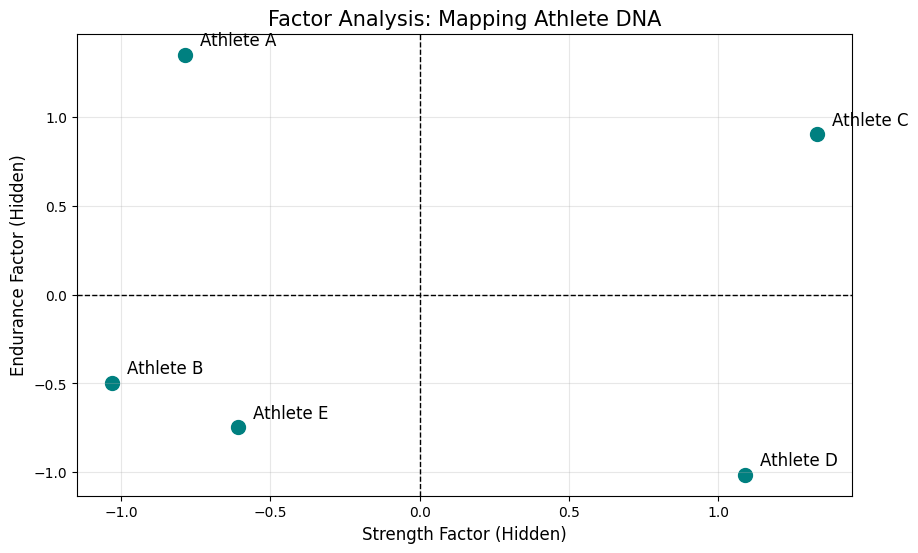

In [3]:
#Visualizng :
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(factors_df['Factor 1 (Strength)'], 
            factors_df['Factor 2 (Endurance)'], 
            color='teal', s=100)

for athlete in factors_df.index:
    plt.text(factors_df.loc[athlete, 'Factor 1 (Strength)'] + 0.05, 
             factors_df.loc[athlete, 'Factor 2 (Endurance)'] + 0.05, 
             athlete, fontsize=12)
    
plt.axhline(0, color='black', lw=1, linestyle='--') # Middle line for Endurance
plt.axvline(0, color='black', lw=1, linestyle='--') # Middle line for Strength
plt.title('Factor Analysis: Mapping Athlete DNA', fontsize=15)
plt.xlabel('Strength Factor (Hidden)', fontsize=12)
plt.ylabel('Endurance Factor (Hidden)', fontsize=12)
plt.grid(alpha=0.3)

plt.show()

We started with a dataset containing 4 distinct physical measurements for each athlete. While we could analyze all 4 columns individually, the Factor Analysis algorithm detected that these measurements naturally group together.

It automatically compressed our 4 columns into 2 hidden factors:
Factor 1 (Strength):The math realized that Bench Press and Push-ups move together. If an athlete is good at one, they are likely good at the other.
Factor 2 (Endurance):It also realized that 5K times and Resting Heart Rates are linked.

By doing this, we turned a messy table of 4 specific exercises into a clean, simplified profile of 2 core fitness traits. This is the exact same math used to simplify massive, complex datasets.